### Data 201 Statistical Methods - Project 1 - Capital Bikeshare Dataset (day.csv)


by Robert Gravatt

#### Introduction
##### 1. Origin of the Dataset
The data utilized in this analysis originates from the UCI Machine Learning Repository, specifically the "Bike Sharing Dataset" (day.csv). This dataset aggregates two years of historical usage logs (2011 and 2012) from the Capital Bikeshare system in Washington, D.C., and combines it with daily meteorological data. The original compilation was conducted by researchers at the Laboratory of Artificial Intelligence and Decision Support (LIAAD) at the University of Porto.

#####2. Population of Interest
The primary population of interest consists of individuals utilizing the Capital Bikeshare network within the Washington, D.C. metropolitan area. This population is subdivided into two distinct cohorts: "casual" riders (those purchasing single-trip or 24-hour passes, often tourists or occasional users) and "registered" riders (those holding monthly or annual memberships, typically local commuters).

#####3. Data Collection Method and Limitations
The dataset was constructed by merging automated, system-generated logs from Capital Bikeshare docking stations with daily weather and seasonal data (including temperature, humidity, wind speed, and holiday schedules). Because the rental system requires user interaction at automated kiosks, the basic transaction counts are highly accurate.

However, there are notable limitations. The data aggregates total daily counts and does not track the exact routes taken through the city's complex road and trail networks. Furthermore, the data only measures successful rentals; it does not capture instances where a user wanted to ride but was prevented by an empty docking station, nor does it track the granular demographic details (age, gender, trip purpose) of the riders due to privacy constraints.

#####4. Potential Ethical and/or Bias Concerns
When analyzing this dataset, several systemic biases must be acknowledged. First, the physical placement of Capital Bikeshare docking stations heavily influences ridership. If stations are disproportionately located in affluent neighborhoods, commercial centers, or tourist hubs—while underserving lower-income residential wards—the data will inherently over-represent the travel patterns of wealthier individuals. Additionally, accessing the service requires a credit or debit card, introducing an economic barrier that entirely excludes unbanked populations from the dataset. Therefore, any conclusions drawn regarding "overall transportation trends" must be qualified by the fact that the sample population is constrained by urban planning decisions and financial access requirements.

### Dataset

**Size and Scope**
The dataset contains 731 rows and 16 columns.

**Row Representation**
Each individual row represents a single, aggregated day of Capital Bikeshare operations between January 1, 2011, and December 31, 2012. It combines the total daily count of bicycle rentals with the specific meteorological conditions and calendar events that occurred on that exact date.

**Table of Variables**
Below is the data dictionary detailing the 16 variables captured in this dataset, along with their definitions and native data types:

| Variable | Definition | Data Type |
| :--- | :--- | :--- |
| **instant** | Record index identifier. | Integer |
| **dteday** | The specific date of the record (YYYY-MM-DD). | Object (String) |
| **season** | Season of the year (1: Spring, 2: Summer, 3: Fall, 4: Winter). | Integer (Categorical) |
| **yr** | Year of the record (0: 2011, 1: 2012). | Integer (Categorical) |
| **mnth** | Month of the year (1 through 12). | Integer |
| **holiday** | Indicates if the day is a recognized holiday (1: Yes, 0: No). | Integer (Boolean) |
| **weekday** | Day of the week (0: Sunday through 6: Saturday). | Integer |
| **workingday** | Indicates if the day is a standard workday (neither a weekend nor a holiday is 1, otherwise 0). | Integer (Boolean) |
| **weathersit** | Weather condition (1: Clear/Partly Cloudy, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Ice). | Integer (Categorical) |
| **temp** | Normalized actual temperature in Celsius. | Float |
| **atemp** | Normalized "feels like" temperature in Celsius. | Float |
| **hum** | Normalized relative humidity. | Float |
| **windspeed** | Normalized wind speed. | Float |
| **casual** | Total daily count of rentals by casual, non-registered users. | Integer |
| **registered** | Total daily count of rentals by registered, annual/monthly members. | Integer |
| **cnt** | Total daily count of all rentals (casual + registered). | Integer |

In [9]:
import pandas as pd

# Load the local dataset
df = pd.read_csv("day.csv")

# Display the first few rows to confirm it loaded
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Output the exact dimensions of the dataset
rows, cols = df.shape
print(f"Dataset Dimensions: {rows} rows and {cols} columns.")

# Display the data types to verify our data dictionary
print("\nData Types:")
print(df.dtypes)

Dataset Dimensions: 731 rows and 16 columns.

Data Types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


### Task 1: The "Commuter vs. Tourist" Effect

**Research Question:** How does the type of day (a standard working day versus a weekend/holiday) impact the composition of Capital Bikeshare users (casual riders vs. registered members)?

**Variables Utilized:** * `workingday` (Categorical)
* `casual` (Quantitative)
* `registered` (Quantitative)

Below, we aggregate the dataset to find the average daily counts for each rider type based on whether it is a standard workday or a weekend/holiday, and visualize the difference using a grouped bar chart.

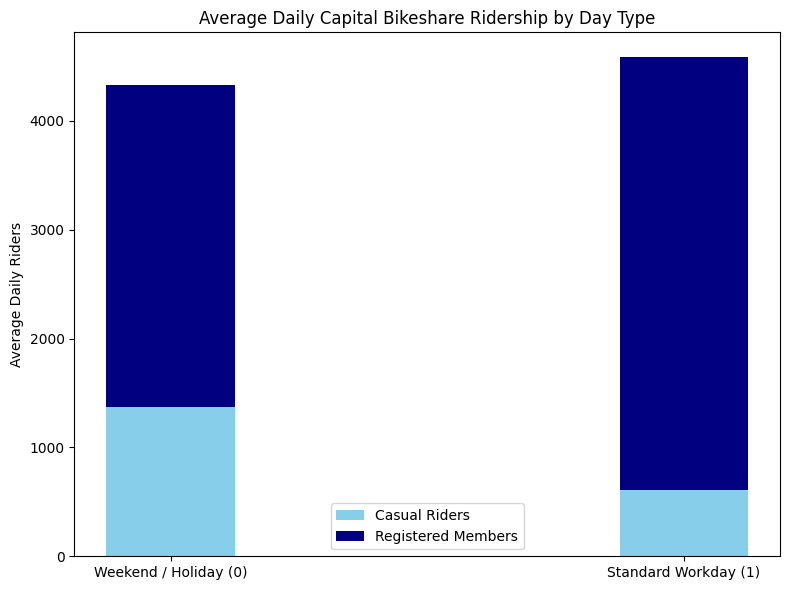

In [5]:
import matplotlib.pyplot as plt

# 1. Group the data by 'workingday' and calculate the mean for casual and registered riders
day_type_avg = df.groupby('workingday')[['casual', 'registered']].mean()

# 2. Set up the bar chart parameters
labels = ['Weekend / Holiday (0)', 'Standard Workday (1)']
casual_means = day_type_avg['casual']
registered_means = day_type_avg['registered']

# Made the bars narrower (was 0.35)
width = 0.25

# 3. Create the stacked plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot casual riders at the bottom
ax.bar(labels, casual_means, width, label='Casual Riders', color='skyblue')

# Plot registered members stacked on top of casual riders
ax.bar(labels, registered_means, width, bottom=casual_means, label='Registered Members', color='navy')

# 4. Add labels, title, and formatting
ax.set_ylabel('Average Daily Riders')
ax.set_title('Average Daily Capital Bikeshare Ridership by Day Type')
ax.legend()

# 5. Display the plot
plt.tight_layout()
plt.show()

**Discussion and Interpretation:**
The stacked bar chart reveals a stark shift in user composition based on the type of day. While the total average daily ridership is slightly higher on standard working days, the system is overwhelmingly utilized by registered members (averaging nearly 4,000 rides), indicating its primary function as a local commuter transit network. Conversely, on weekends and holidays, while the overall volume drops slightly, the proportion of casual riders more than doubles. This shift perfectly visualizes the system pivoting from commuter transit to a recreational and tourist amenity on non-working days.

### Task 2: The Temperature Threshold

**Research Question:** What is the relationship between the "feels like" temperature and the total daily volume of bike rentals, and is there a threshold where extreme heat begins to deter riders?

**Variables Utilized:** * `atemp` (Quantitative: Normalized "feels like" temperature)
* `cnt` (Quantitative: Total daily rentals)

Below, we use a scatter plot with a second-degree polynomial trendline to visualize how ridership responds to increasing temperatures, looking specifically for a plateau or decline at the highest temperature ranges.

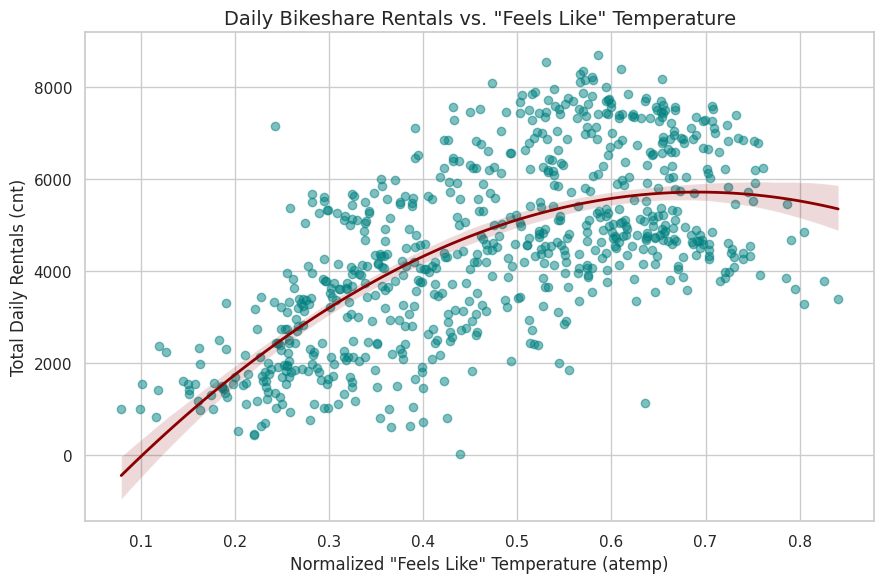

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size and style of the plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create a scatter plot with an order-2 polynomial trendline to capture the curve
sns.regplot(
    x='atemp',
    y='cnt',
    data=df,
    order=2,
    scatter_kws={'alpha': 0.5, 'color': 'teal'},
    line_kws={'color': 'darkred', 'linewidth': 2}
)

# Add labels and title
plt.title('Daily Bikeshare Rentals vs. "Feels Like" Temperature', fontsize=14)
plt.xlabel('Normalized "Feels Like" Temperature (atemp)', fontsize=12)
plt.ylabel('Total Daily Rentals (cnt)', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

**Discussion and Interpretation:**
The scatter plot demonstrates a strong positive correlation between temperature and daily bike rentals for the majority of the year; as the "feels like" temperature rises, ridership steadily increases. However, the polynomial trendline reveals a distinct threshold effect at the upper extremes of the temperature scale. When the normalized `atemp` reaches its highest values—representing the peak heat and humidity of mid-summer—total daily ridership begins to plateau and eventually decline. This suggests that while warm weather generally encourages biking, extreme heat creates a ceiling effect where conditions become too uncomfortable or potentially unsafe for a portion of the user base.

### Task 3: The Impact of Adverse Weather

**Research Question:** To what extent do varying weather conditions (from clear skies to light snow/rain) impact the total number of daily Capital Bikeshare rentals?

**Variables Utilized:** * `weathersit` (Categorical: 1=Clear, 2=Mist/Cloudy, 3=Light Snow/Rain, 4=Heavy Rain/Ice)
* `cnt` (Quantitative: Total daily rentals)

Below, we utilize side-by-side box plots to visualize the distribution of daily ridership across different weather classifications. This allows us to compare not just the median ridership, but the overall variance and extremes within each weather condition.

/tmp/ipykernel_35291/4203191154.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


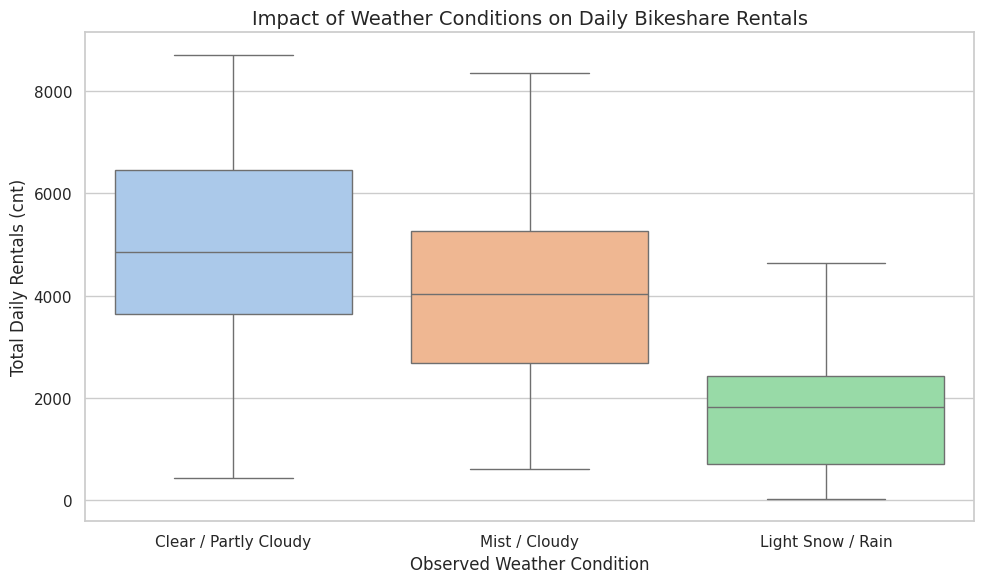

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the numeric weather situations to readable labels for the chart
weather_labels = {
    1: 'Clear / Partly Cloudy',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Rain',
    4: 'Heavy Rain / Ice'
}

# Create a temporary column for the chart labels
df['weather_desc'] = df['weathersit'].map(weather_labels)

# 2. Set up the plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the box plot
sns.boxplot(
    x='weather_desc',
    y='cnt',
    data=df,
    order=['Clear / Partly Cloudy', 'Mist / Cloudy', 'Light Snow / Rain'],
    palette='pastel'
)

# 4. Add labels and title
plt.title('Impact of Weather Conditions on Daily Bikeshare Rentals', fontsize=14)
plt.xlabel('Observed Weather Condition', fontsize=12)
plt.ylabel('Total Daily Rentals (cnt)', fontsize=12)

# 5. Display the plot
plt.tight_layout()
plt.show()

# Note: The 'Heavy Rain / Ice' category (4) doesn't appear in the daily dataset
# because a full 24 hours of extreme weather is rare, so we omit it from the order.

**Discussion and Interpretation:**
The side-by-side box plots clearly illustrate a negative relationship between adverse weather conditions and daily bikeshare usage. Days classified as "Clear / Partly Cloudy" exhibit the highest median ridership and the widest interquartile range, indicating that favorable weather consistently draws the largest, albeit most variable, volume of riders. As weather degrades to "Mist / Cloudy," the median drops noticeably. On days experiencing "Light Snow / Rain," ridership plummets, with the 75th percentile of rainy days falling below the 25th percentile of clear days. This confirms that precipitation is a primary deterrent to ridership, severely limiting system utility on those days.

### Task 4: Confidence in Ridership (A Statistical Simulation)

**Research Question:** If Capital Bikeshare planners need to estimate the average daily ridership for logistical and fleet planning, what is the simulated distribution of the mean daily ridership across a random sample of days?

**Variables Utilized:** * `cnt` (Quantitative: Total daily rentals)

Below, we utilize a bootstrap simulation to demonstrate the Central Limit Theorem. We randomly draw 1,000 samples (each consisting of 30 days of data, with replacement) from our dataset, calculate the mean ridership for each sample, and plot the frequency distribution of those sample means.

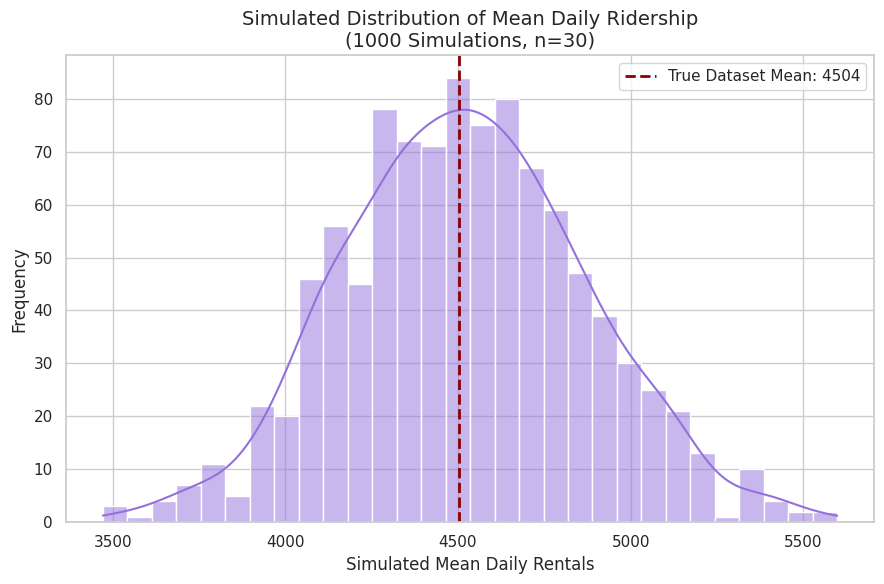

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the total daily counts as an array
counts = df['cnt'].values

# 2. Define our simulation parameters
sample_size = 30
num_simulations = 1000
sample_means = []

# 3. Run the bootstrap simulation
np.random.seed(42) # Set a seed so the results are exactly reproducible for grading
for _ in range(num_simulations):
    # Draw a random sample of 30 days (with replacement)
    sample = np.random.choice(counts, size=sample_size, replace=True)
    # Calculate the mean of that sample and store it
    sample_means.append(np.mean(sample))

# 4. Set up the plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# 5. Plot the histogram with a KDE (Kernel Density Estimate) curve
sns.histplot(sample_means, kde=True, color='mediumpurple', bins=30)

# 6. Add a vertical line to show the true population mean of our dataset
true_mean = np.mean(counts)
plt.axvline(true_mean, color='darkred', linestyle='dashed', linewidth=2,
            label=f'True Dataset Mean: {true_mean:.0f}')

# 7. Add labels and title
plt.title(f'Simulated Distribution of Mean Daily Ridership\n({num_simulations} Simulations, n={sample_size})', fontsize=14)
plt.xlabel('Simulated Mean Daily Rentals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# 8. Display the plot
plt.tight_layout()
plt.show()

**Discussion and Interpretation:**
The histogram resulting from our bootstrap simulation displays a classic normal distribution, physically demonstrating the Central Limit Theorem in action. Even though the underlying daily ridership data is subject to extreme seasonal and weather-related variance, the distribution of the *sample means* tightly clusters around the true dataset average of roughly 4,504 rides per day. For Capital Bikeshare planners, this simulation provides statistical confidence that an expected average of approximately 4,500 daily rides is a highly reliable metric for long-term fleet management and financial forecasting, effectively smoothing out the daily volatility.

### Conclusions and Recommendations

**Summary of Findings**
Based on the exploratory data analysis and simulation, several clear associations dictate Capital Bikeshare usage. Weather is a primary driver of ridership volume; the polynomial trendline in Task 2 demonstrates a clear threshold where extreme heat and humidity begin to deter riders, and the box plots in Task 3 confirm that precipitation severely depresses median daily usage. Interestingly, the stacked bar chart in Task 1 reveals that while the *composition* of users shifts dramatically—from registered commuters on weekdays to casual tourists on weekends—the overall daily volume remains relatively stable.

**Areas Lacking Significance**
Because the total volume of daily rentals remains fairly consistent across the week, the binary `workingday` variable is not a practically significant predictor of *total* fleet demand. There isn't anything of statistical interest in using the day of the week to forecast raw volume, as the commuter drop-off on weekends is almost perfectly offset by the influx of casual recreational riders.

**Recommendations for Further Statistical Analysis**
While the bootstrap simulation in Task 4 provides a reliable confidence interval for the overall population mean, further statistical modeling is recommended to make predictive operational decisions. I recommend developing a multiple linear regression model to predict total daily rentals (`cnt`) based on a combination of `atemp`, `weathersit`, and `season`. In doing so, it will be critical to test for multicollinearity, as temperature and season are inherently correlated. Furthermore, because this dataset represents sequential daily records, applying time-series forecasting (such as an ARIMA model) would be a rigorous next step to account for the temporal autocorrelation that simple random sampling ignores.